resources: 
* https://youtu.be/77QH0Y2PYKg?si=lQi_TFqthGzgVLyp
* https://www.pinecone.io/learn/series/faiss/hnsw/

Goal of vector search is to find the most similar vectors to a query vector. But how does it implemented?

## NSW(Navigable Small World)

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

[INFO] Start node: 8 Distance: 0.9618
[Node 8] List of neighbors: [12]
  [Node 8] Neighbor: 12 - Distance: 0.8070
[INFO] Found closer neighbor: 12 - Distance: 0.8070
[INFO] Moving to neighbor: 12 - Distance: 0.8070
[Node 12] List of neighbors: [2, 7, 8]
  [Node 12] Neighbor: 2 - Distance: 0.5175
[INFO] Found closer neighbor: 2 - Distance: 0.5175
  [Node 12] Neighbor: 7 - Distance: 0.9073
  [Node 12] Neighbor: 8 - Distance: 0.9618
[INFO] Moving to neighbor: 2 - Distance: 0.5175
[Node 2] List of neighbors: [11, 12, 1, 0, 3]
  [Node 2] Neighbor: 11 - Distance: 0.5512
  [Node 2] Neighbor: 12 - Distance: 0.8070
  [Node 2] Neighbor: 1 - Distance: 0.3145
[INFO] Found closer neighbor: 1 - Distance: 0.3145
  [Node 2] Neighbor: 0 - Distance: 0.4422
  [Node 2] Neighbor: 3 - Distance: 0.6414
[INFO] Moving to neighbor: 1 - Distance: 0.3145
[Node 1] List of neighbors: [0, 5, 11, 2]
  [Node 1] Neighbor: 0 - Distance: 0.4422
  [Node 1] Neighbor: 5 - Distance: 0.1361
[INFO] Found closer neighbor: 5 - D

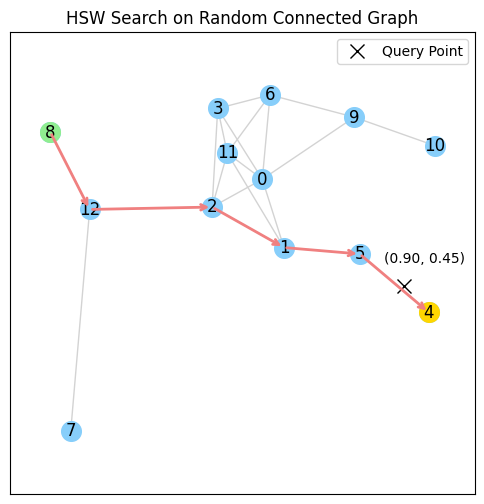

In [68]:
def create_random_connected_graph(num_nodes=13, threshold=0.3, seed=42):
    """
    Creates a connected graph of num_nodes placed randomly in 2D.
    1) All nodes are connected via a Minimum Spanning Tree (so there's exactly one component).
    2) Each node can add up to 2 more edges with neighbors within threshold (randomly chosen).
    """
    np.random.seed(seed)
    G = nx.Graph()
    positions = {}

    # Step 1: Create random nodes
    for i in range(num_nodes):
        x, y = np.random.rand(2)
        G.add_node(i)
        positions[i] = (float(x), float(y))

    # Step 2: Build a complete graph in memory just to compute MST distances
    complete_graph = nx.Graph()
    for i in range(num_nodes):
        complete_graph.add_node(i)

    # Add edges with weight = Euclidean distance
    for i in range(num_nodes):
        x_i, y_i = positions[i]
        for j in range(i+1, num_nodes):
            x_j, y_j = positions[j]
            dist = np.sqrt((x_i - x_j)**2 + (y_i - y_j)**2)
            complete_graph.add_edge(i, j, weight=dist)

    # Compute MST on the complete graph
    mst = nx.minimum_spanning_tree(complete_graph, weight='weight')

    # Add MST edges to G (guarantees connectivity)
    for (u, v) in mst.edges():
        G.add_edge(u, v)

    # Step 3: Optionally add more edges if neighbors are within threshold
    #         up to 2 extra edges per node
    for i in range(num_nodes):
        x_i, y_i = positions[i]
        # Find candidates within threshold
        candidate_nodes = []
        for j in range(num_nodes):
            if i == j:
                continue
            x_j, y_j = positions[j]
            dist = np.sqrt((x_i - x_j)**2 + (y_i - y_j)**2)
            if dist <= threshold:
                candidate_nodes.append(j)

        # Shuffle and pick up to 2 candidates that are not already connected in G
        np.random.shuffle(candidate_nodes)
        extra_edges = 0
        for c in candidate_nodes:
            if not G.has_edge(i, c):
                G.add_edge(i, c)
                extra_edges += 1
                if extra_edges == 2:
                    break

    return G, positions

def euclidean_distance(a, b):
    """Compute Euclidean distance between points a and b."""
    return np.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)

def hsw_search(G: nx.Graph, positions: dict[int, tuple], query_point: tuple[float, float], start_node: int):
    """
    Perform a greedy, navigable small-world (HSW) search on the graph to find the node
    closest to query_point. Starting from start_node, the algorithm moves to a neighbor
    that is strictly closer (in Euclidean distance) to the query point until a local minimum
    is reached.
    
    Returns:
        current_node : the node at which the search stops (approximate nearest neighbor)
        path         : list of nodes visited during the search
    """
    current_node = start_node
    path = [current_node]
    current_distance = euclidean_distance(positions[current_node], query_point)
    print(f'[INFO] Start node: {current_node} Distance: {current_distance:.4f}')
    while True:
        neighbors = list(G.neighbors(current_node))
        best_neighbor = None
        best_distance = current_distance
        print(f'[Node {current_node}] List of neighbors: {neighbors}')
        for nbr in neighbors:
            nbr_distance = euclidean_distance(positions[nbr], query_point)
            print(f'  [Node {current_node}] Neighbor: {nbr} - Distance: {nbr_distance:.4f}')
            if nbr_distance < best_distance:
                print(f'[INFO] Found closer neighbor: {nbr} - Distance: {nbr_distance:.4f}')
                best_distance = nbr_distance
                best_neighbor = nbr
        
        if best_neighbor is not None:
            current_node = best_neighbor
            current_distance = best_distance
            path.append(current_node)
            print(f'[INFO] Moving to neighbor: {current_node} - Distance: {current_distance:.4f}')
        else:
            # No neighbor is closer: reached local minimum.
            break
    
    return current_node, path

# 1. Create the connected graph using your provided function.
num_nodes = 13
threshold = 0.3
seed = 0
G, positions = create_random_connected_graph(num_nodes, threshold, seed)

# 2. Define a random query point in the same [0,1] x [0,1] domain.
query_point = tuple(map(float, np.random.rand(2)))

# 3. Choose a random starting node from the graph.
start_node = int(np.random.choice(list(G.nodes())))

# 4. Perform HSW greedy search starting from start_node.
nearest_node, search_path = hsw_search(G, positions, query_point, start_node)

print("Query point:", query_point)
print("Start node:", start_node)
print("Nearest node found:", nearest_node)
print("Search path:", search_path)

# 5. Visualize the graph and search path.

node_size = 200
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

# Draw all graph edges in light gray.
nx.draw_networkx_edges(G, positions, edge_color="lightgray", ax=ax)
# Draw all nodes in blue.
nx.draw_networkx_nodes(G, positions, node_color="lightskyblue", ax=ax, node_size=node_size)
nx.draw_networkx_labels(G, positions, font_color="black", ax=ax)

# Highlight the search path in red.
path_edges = list(zip(search_path, search_path[1:]))
# Draw the search path with red arrows.
for i in range(len(search_path) - 1):
    start_pos = positions[search_path[i]]
    end_pos = positions[search_path[i+1]]
    plt.annotate("",
                    xy=end_pos,
                    xytext=start_pos,
                    arrowprops=dict(arrowstyle="->", color="lightcoral", lw=2),
                    )
# nx.draw_networkx_edges(G, positions, edgelist=path_edges, edge_color="red", width=2, ax=ax)

# Highlight the start node (green) and the found nearest node (yellow).
nx.draw_networkx_nodes(G, positions, nodelist=[start_node], node_color="lightgreen", node_size=node_size, ax=ax)
nx.draw_networkx_nodes(G, positions, nodelist=[nearest_node], node_color="gold", node_size=node_size, ax=ax)

# Mark the query point with a black "X".
ax.plot(query_point[0], query_point[1], 'kx', markersize=10, label="Query Point")
# plot text of query point
ax.text(query_point[0]-0.05, query_point[1]+0.05, f"({query_point[0]:.2f}, {query_point[1]:.2f})", 
        fontsize=10, verticalalignment='bottom')
ax.set_title("HSW Search on Random Connected Graph")
ax.axis("equal")
plt.legend()
plt.show()

## Probability Skip List

The probability skip list was introduced way back in 1990 by William Pugh [1]

[1] Pugh, William. "Skip lists: a probabilistic alternative to balanced trees." Communications of the ACM 33.6 (1990): 668-676.

Inserting numbers: [4, 8, 12, 19, 33, 35, 49, 71, 92, 97]

Skip List:
Level 0: 4 8 12 19 33 35 49 71 92 97 
Level 1: 4 8 33 71 97 
Level 2: 4 8 33 71 97 

Searching for 25 in the skip list.
Value 25 not found; search reached the closest node.


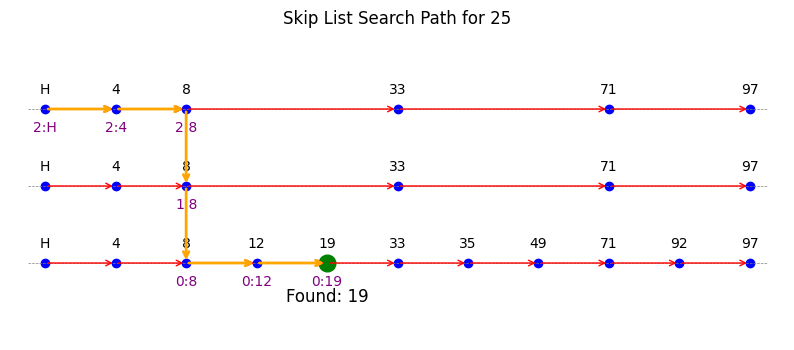

In [84]:
import random 

class SkipListNode:
    def __init__(self, value, level):
        self.value = value
        # forward pointers for levels 0 to level
        self.forward = [None] * (level + 1)
        
    def __repr__(self):
        return f"SkipListNode({self.value}, level={len(self.forward)-1})"

class SkipList:
    def __init__(self, max_level=2, p=0.5, debug=False):
        """
        Create a skip list with max_level (levels 0,1,2) and probability factor p.
        """
        self.max_level = max_level
        self.p = p
        self.header = SkipListNode(None, max_level)
        self.level = 0  # current highest level
        self.debug = debug

    def random_level(self):
        lvl = 0
        while random.random() < self.p and lvl < self.max_level:
            lvl += 1
        return lvl

    def insert(self, value):
        if self.debug:
            print(f"\nInserting {value}...")
        update = [None] * (self.max_level + 1)
        current = self.header

        # Find the insertion point at each level
        for i in range(self.level, -1, -1):
            if self.debug:
                print(f"  Level {i}: ", end="")
            while current.forward[i] and current.forward[i].value < value:
                if self.debug:
                    print(f"{current.forward[i].value} -> ", end="")
                current = current.forward[i]
            update[i] = current
            if self.debug:
                print(f"Update[{i}] = {current.value if current.value is not None else 'Header'}")

        current = current.forward[0]

        # Only insert if the value is not already present
        if current is None or current.value != value:
            rlevel = self.random_level()
            if self.debug:
                print(f"  Random level chosen for {value} is {rlevel}")
            if rlevel > self.level:
                for i in range(self.level + 1, rlevel + 1):
                    update[i] = self.header
                    if self.debug:
                        print(f"  Upgrading update[{i}] to Header")
                self.level = rlevel
            new_node = SkipListNode(value, rlevel)
            # Insert new_node by updating pointers at each level up to rlevel.
            for i in range(rlevel + 1):
                new_node.forward[i] = update[i].forward[i]
                update[i].forward[i] = new_node
                if self.debug:
                    print(f"  Level {i}: Inserted {value} after {update[i].value if update[i].value is not None else 'Header'}")
        else:
            if self.debug:
                print(f"  Value {value} already exists. Skipping insertion.")

    def search(self, value):
        current = self.header
        for i in range(self.level, -1, -1):
            while current.forward[i] and current.forward[i].value < value:
                current = current.forward[i]
        current = current.forward[0]
        if current and current.value == value:
            return current
        return None

    def search_with_path(self, value):
        """
        Search for 'value' and record the search path as a list of (level, node) tuples.
        The path records the node visited at each level during the search.
        """
        path = []
        current = self.header
        # Search from highest level to level 0
        for i in range(self.level, -1, -1):
            # Record starting point at level i
            path.append((i, current))
            while current.forward[i] and current.forward[i].value < value:
                current = current.forward[i]
                path.append((i, current))
        current = current.forward[0]
        if current and current.value == value:
            path.append((0, current))
            return current, path
        else:
            return None, path

    def display_list(self):
        print("\nSkip List:")
        for i in range(self.level + 1):
            current = self.header.forward[i]
            print(f"Level {i}: ", end="")
            while current:
                print(current.value, end=" ")
                current = current.forward[i]
            print("")

    def get_ordered_nodes(self):
        """Return a list of nodes (including header) in level 0 order."""
        nodes = []
        current = self.header
        while current:
            nodes.append(current)
            current = current.forward[0]
        return nodes

def visualize_skip_list(skiplist):
    """
    Visualizes the skip list structure using matplotlib.
    - Nodes are arranged horizontally in order.
    - Each level (0, 1, 2) is drawn on its own horizontal line.
    - Red arrows represent forward pointers.
    - Each node is annotated with its value ("H" for header).
    Returns a dictionary mapping node -> x-coordinate.
    """
    ordered_nodes = skiplist.get_ordered_nodes()
    spacing = 2  # horizontal spacing between nodes
    node_x = {node: idx * spacing for idx, node in enumerate(ordered_nodes)}
    top_level = skiplist.max_level

    plt.figure(figsize=(10, 4))
    
    # For each level (draw from top to bottom)
    for level in range(top_level, -1, -1):
        # Draw nodes that are present at this level (i.e. node has a forward pointer at that level)
        for node in ordered_nodes:
            if len(node.forward) - 1 >= level:  # node is present at this level
                x = node_x[node]
                y = level
                plt.plot(x, y, 'o', color='blue')
                # Label node: header as "H", others by value.
                label = "H" if node.value is None else str(node.value)
                plt.text(x, y + 0.2, label, ha='center', fontsize=10)
        # Draw arrows for forward pointers at this level.
        for node in ordered_nodes:
            if len(node.forward) - 1 >= level:
                next_node = node.forward[level]
                if next_node is not None:
                    start = (node_x[node], level)
                    end = (node_x[next_node], level)
                    plt.annotate("",
                                 xy=end, xytext=start,
                                 arrowprops=dict(arrowstyle="->", color="red"))
        # Optional: draw a dashed horizontal line for the level.
        xs = [node_x[node] for node in ordered_nodes if len(node.forward) - 1 >= level]
        if xs:
            plt.hlines(level, min(xs)-0.5, max(xs)+0.5, colors='gray', linestyles='dashed', linewidth=0.5)

    plt.ylim(-1, top_level+1)
    plt.xlim(-1, node_x[ordered_nodes[-1]]+1)
    plt.title("Skip List Visualization with Arrows and Node Labels")
    plt.axis('off')
    return node_x  # so we can position search path arrows accordingly

def visualize_search_path(skiplist, search_path, node_x):
    """
    Overlays the search path on the skip list visualization.
    search_path: list of (level, node) tuples from the search_with_path method.
    node_x: mapping of node to x-coordinate (from visualize_skip_list).
    Draws orange arrows representing the search path and annotates each visited node 
    with its level. For header nodes, the label is "level:H".
    """
    # Annotate each node in the search path with its label, including the level number.
    for (level, node) in search_path:
        if node.value is None:
            label = f"{level}:H"
        else:
            label = f"{level}:{node.value}"
        plt.text(node_x[node], level - 0.3, label, ha='center', fontsize=10, color='purple')
        
    # Draw orange arrows between consecutive nodes in the search path.
    for i in range(len(search_path) - 1):
        level1, node1 = search_path[i]
        level2, node2 = search_path[i+1]
        start = (node_x[node1], level1)
        end = (node_x[node2], level2)
        plt.annotate("",
                     xy=end, xytext=start, alpha=0.5,
                     arrowprops=dict(arrowstyle="->", color="orange", lw=2))
    
    # Highlight the final node found (or reached) with a green marker.
    final_level, final_node = search_path[-1]
    plt.plot(node_x[final_node], final_level, 'o', color='green', markersize=12)
    plt.text(node_x[final_node], final_level - 0.5, f"Found: {final_node.value}", 
             ha='center', fontsize=12)


# --------------------- Main Usage --------------------- #
# Create a skip list with 3 levels (0,1,2)
sl = SkipList(max_level=2, p=0.5, debug=False)

# Insert 10 random integers (sample without replacement from 1 to 100)
numbers = random.sample(range(1, 101), 10)
print("Inserting numbers:", sorted(numbers))
for num in sorted(numbers):
    sl.insert(num)

sl.display_list()

# Give a random number to search for (it may or may not be in the list)
search_val = random.choice(range(1, 101))
print(f"\nSearching for {search_val} in the skip list.")
result, search_path = sl.search_with_path(search_val)
if result:
    print(f"Value {search_val} found in skip list.")
else:
    print(f"Value {search_val} not found; search reached the closest node.")

# Visualize the skip list and overlay the search path.
node_x = visualize_skip_list(sl)
visualize_search_path(sl, search_path, node_x)
plt.title(f"Skip List Search Path for {search_val}")
plt.show()

## HNSW(Hierachical Navigable Small World)

Inserting vectors:
[0.37454012 0.95071431]
[0.73199394 0.59865848]
[0.15601864 0.15599452]
[0.05808361 0.86617615]
[0.60111501 0.70807258]
[0.02058449 0.96990985]
[0.83244264 0.21233911]
[0.18182497 0.18340451]
[0.30424224 0.52475643]
[0.43194502 0.29122914]
[0.61185289 0.13949386]
[0.29214465 0.36636184]
[0.45606998 0.78517596]
[0.19967378 0.51423444]
[0.59241457 0.04645041]


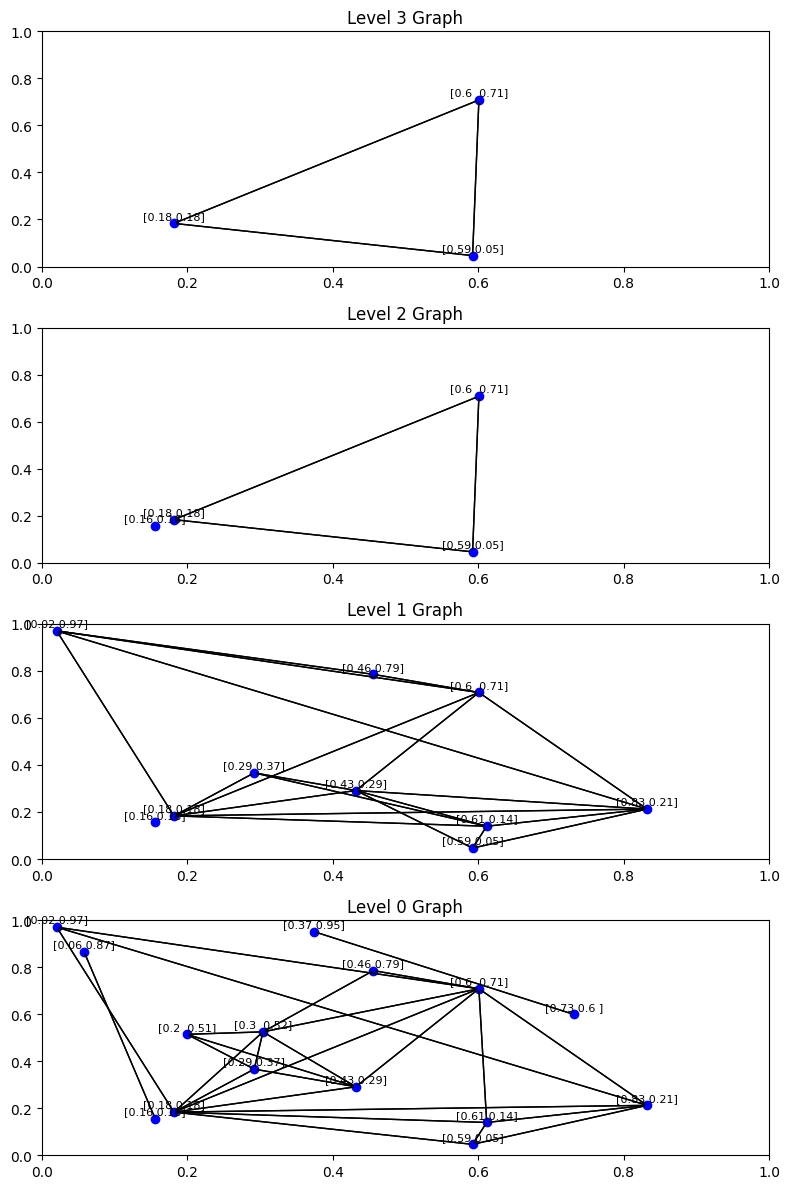


Query vector: [0.60754485 0.17052412]
Level 3 search path:
  HNSWNode([0.6 ,0.71], level=3) (distance: 0.5376)
  HNSWNode([0.18,0.18], level=3) (distance: 0.4259)
  HNSWNode([0.59,0.05], level=3) (distance: 0.1250)

Level 2 search path:
  HNSWNode([0.59,0.05], level=3) (distance: 0.1250)

Level 1 search path:
  HNSWNode([0.59,0.05], level=3) (distance: 0.1250)
  HNSWNode([0.61,0.14], level=1) (distance: 0.0313)

Level 0 search path:
  HNSWNode([0.61,0.14], level=1) (distance: 0.0313)



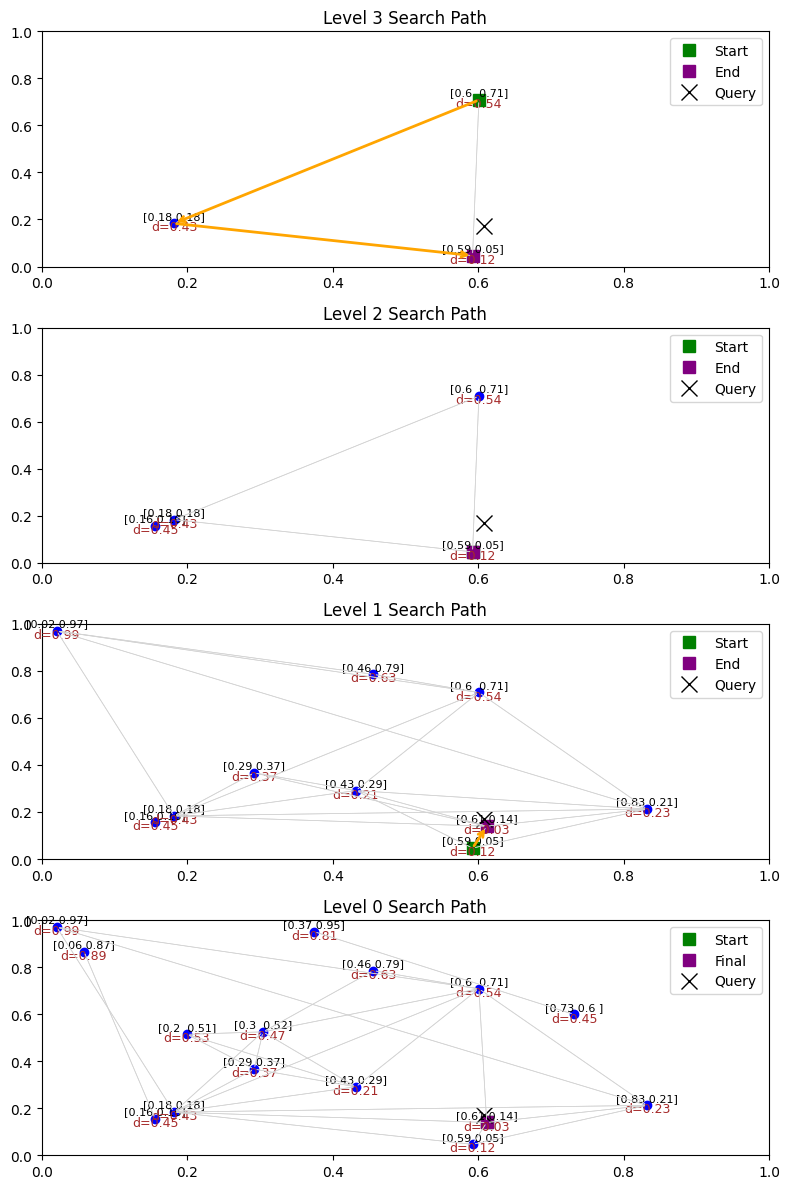


Nearest node found:
HNSWNode([0.61,0.14], level=1)
Distance: 0.031327886251450894


In [118]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt

def distance(a, b):
    """Euclidean distance between two vectors a and b."""
    return np.linalg.norm(a - b)

class HNSWNode:
    def __init__(self, vector, level):
        self.vector = vector  # now stores an np.ndarray
        self.level = level
        # Each level (0 ... level) holds a list of neighbor nodes.
        self.neighbors = {l: [] for l in range(level + 1)}
    
    def __repr__(self):
        # For brevity, display a rounded version of the vector.
        vec_str = np.array2string(self.vector, precision=2, separator=',')
        return f"HNSWNode({vec_str}, level={self.level})"

class HNSWIndex:
    def __init__(self, M=3, max_allowed_level=5, p=0.5):
        """
        Initialize the HNSW index.
        
        Parameters:
          M: maximum number of neighbors per node (per layer).
          max_allowed_level: maximum level any node can have.
          p: probability factor to determine node level (exponentially decreasing).
        """
        self.M = M
        self.max_allowed_level = max_allowed_level
        self.p = p
        self.entry_point = None
        self.max_level = -1  # current highest level in the index
        self.nodes = []      # list of all nodes in the index

    def random_level(self):
        """Generate a random level for a new node (levels 0 ... max_allowed_level)."""
        lvl = 0
        while random.random() < self.p and lvl < self.max_allowed_level:
            lvl += 1
        return lvl

    def _greedy_search_layer(self, query, entry, level, record_path=False):
        """
        Perform a greedy search on a given layer (level) starting from 'entry'
        to find a node that is (locally) near the query.
        If record_path is True, returns (final_node, path) where path is a list of nodes visited.
        Otherwise, returns final_node.
        """
        current = entry
        current_dist = distance(query, current.vector)
        path = [current] if record_path else None
        while True:
            improved = False
            for neighbor in current.neighbors.get(level, []):
                d = distance(query, neighbor.vector)
                if d < current_dist:
                    current = neighbor
                    current_dist = d
                    if record_path:
                        path.append(current)
                    improved = True
                    break  # move to the next iteration with the new current node
            if not improved:
                break
        return (current, path) if record_path else current

    def insert(self, vector):
        """
        Insert a new node with the given vector into the HNSW index.
        For each level (from new node's level down to 0), perform a greedy search
        starting from the current entry point and connect the new node with up to M nearest neighbors.
        """
        node_level = self.random_level()
        new_node = HNSWNode(vector, node_level)
        self.nodes.append(new_node)
        
        # If this is the first node, set it as the entry point.
        if self.entry_point is None:
            self.entry_point = new_node
            self.max_level = node_level
            return new_node

        # Update entry point if the new node has a higher level.
        if node_level > self.max_level:
            self.entry_point = new_node
            self.max_level = node_level

        current_candidate = self.entry_point
        for lvl in range(min(node_level, self.max_level), -1, -1):
            current_candidate = self._greedy_search_layer(vector, current_candidate, lvl)
            candidate_list = [current_candidate] + current_candidate.neighbors.get(lvl, [])
            candidate_list.sort(key=lambda node: distance(vector, node.vector))
            selected_neighbors = candidate_list[:self.M]
            for neighbor in selected_neighbors:
                if neighbor not in new_node.neighbors[lvl]:
                    new_node.neighbors[lvl].append(neighbor)
                if new_node not in neighbor.neighbors.get(lvl, []):
                    neighbor.neighbors[lvl].append(new_node)
        return new_node

    def search(self, query):
        """
        Greedy search for the nearest node to the query vector (without ef exploration).
        """
        current = self.entry_point
        for lvl in range(self.max_level, -1, -1):
            current = self._greedy_search_layer(query, current, lvl)
        return current

    def get_extended_neighbors(self, node, level, max_k):
        """
        Return a set of nodes that are within max_k hops (neighbors, neighbors of neighbors, etc.)
        starting from the given node on a specific level.
        """
        extended = set()
        frontier = {node}
        for _ in range(max_k):
            next_frontier = set()
            for n in frontier:
                for neighbor in n.neighbors.get(level, []):
                    if neighbor not in extended:
                        extended.add(neighbor)
                        next_frontier.add(neighbor)
            if not next_frontier:
                break
            frontier = next_frontier
        return extended

    def search_ef_with_path(self, query, ef, max_k=1):
        """
        Perform a search at level 0 using the ef parameter while recording the order in which nodes are visited.
        This version expands the candidate set using not only direct neighbors but also their neighbors up to max_k hops.
        It uses a global best distance as a stopping criterion.
        
        Parameters:
          query: query vector.
          ef: exploration parameter (max candidate list size).
          max_k: maximum hops to extend neighbors (max_k=1 means only direct neighbors).
        
        Returns a tuple: (best_candidate, visited_list) where visited_list is the list of nodes in the order they were expanded.
        """
        # Descend from higher levels to get an initial candidate at level 0.
        current = self.entry_point
        for lvl in range(self.max_level, 0, -1):
            current = self._greedy_search_layer(query, current, lvl)
        best_candidate = current
        best_dist = distance(query, current.vector)
        
        visited = set([current])
        visited_list = [current]
        
        candidate_list = [(best_dist, current)]
        candidate_list.sort(key=lambda x: x[0])
        
        while candidate_list and candidate_list[0][0] < best_dist:
            d, candidate = candidate_list.pop(0)
            # Expand candidate's neighbors (extended up to max_k hops)
            extended_neighbors = self.get_extended_neighbors(candidate, level=0, max_k=max_k)
            # Also include candidate's direct neighbors.
            extended_neighbors = extended_neighbors.union(set(candidate.neighbors.get(0, [])))
            for neighbor in extended_neighbors:
                if neighbor in visited:
                    continue
                visited.add(neighbor)
                visited_list.append(neighbor)
                d_neighbor = distance(query, neighbor.vector)
                if d_neighbor < best_dist:
                    best_dist = d_neighbor
                    best_candidate = neighbor
                # Insert neighbor into candidate list if appropriate.
                candidate_list.append((d_neighbor, neighbor))
                candidate_list.sort(key=lambda x: x[0])
                # Limit candidate list to size ef.
                if len(candidate_list) > ef:
                    candidate_list = candidate_list[:ef]
        return best_candidate, visited_list

    def search_with_path(self, query, ef, max_k=1):
        """
        Perform a hierarchical search with path recording.
        For levels above 0, use greedy search with path recording.
        At level 0, use ef search with path recording (with extended neighbor exploration using max_k).
        Returns a dictionary mapping level -> list of nodes visited during search.
        """
        paths = {}
        current = self.entry_point
        for lvl in range(self.max_level, 0, -1):
            current, path = self._greedy_search_layer(query, current, lvl, record_path=True)
            paths[lvl] = path
        best_candidate, path0 = self.search_ef_with_path(query, ef, max_k)
        paths[0] = path0
        return paths

# ----------------- Visualization Functions ----------------- #

def visualize_hnsw_levels(hnsw):
    """
    Visualize the full graph of each level in the HNSW index.
    For each level, plot the nodes (using their 2D vector coordinates) and draw red arrows for edges.
    """
    max_lvl = hnsw.max_level
    fig, axes = plt.subplots(max_lvl+1, 1, figsize=(8, (max_lvl+1)*3))
    if max_lvl+1 == 1:
        axes = [axes]
    for lvl in range(max_lvl, -1, -1):
        ax = axes[max_lvl - lvl]
        ax.set_title(f"Level {lvl} Graph")
        # Get nodes that exist at this level (node.level >= lvl)
        nodes = [node for node in hnsw.nodes if node.level >= lvl]
        # Plot nodes and annotate with their coordinates.
        for node in nodes:
            x, y = node.vector
            ax.plot(x, y, 'o', color='blue')
            ax.text(x, y+0.02, f"{node.vector.round(2)}", fontsize=8, ha='center')
        # Plot edges (neighbors at this level)
        for node in nodes:
            for neighbor in node.neighbors.get(lvl, []):
                if neighbor in nodes:  # Only draw if neighbor is in the same level
                    x1, y1 = node.vector
                    x2, y2 = neighbor.vector
                    ax.annotate("",
                                xy=(x2, y2), xytext=(x1, y1),
                                arrowprops=dict(arrowstyle="-", color="black", lw=1))
        ax.set_xlim(0,1)
        ax.set_ylim(0,1)
    plt.tight_layout()
    plt.show()

def visualize_hnsw_search_paths(hnsw, search_paths, query_vector, ef, max_k=1):
    """
    For each level, overlay the search path (recorded in search_paths)
    on top of the graph for that level, plot the query vector, and display
    the distance from each node to the query.
    
    For level 0, if the final best candidate is not in the search path,
    an extra arrow is drawn (only if the nodes are actually linked).
    
    Parameters:
      hnsw: the HNSW index.
      search_paths: dict mapping level -> list of nodes visited during search.
      query_vector: a 2D np.ndarray representing the query.
      ef: exploration parameter used in search.
      max_k: maximum hops for extended neighbor exploration.
    """
    import matplotlib.pyplot as plt  # ensure plt is imported
    max_lvl = hnsw.max_level
    fig, axes = plt.subplots(max_lvl+1, 1, figsize=(8, (max_lvl+1)*3))
    if max_lvl+1 == 1:
        axes = [axes]
        
    # Determine the final best candidate at level 0.
    best_candidate, _ = hnsw.search_ef_with_path(query_vector, ef, max_k)
    
    for lvl in range(max_lvl, -1, -1):
        ax = axes[max_lvl - lvl]
        ax.set_title(f"Level {lvl} Search Path")
        # Nodes present at this level: nodes with node.level >= lvl.
        nodes = [node for node in hnsw.nodes if node.level >= lvl]
        # Plot the full graph (nodes and light-gray edges).
        for node in nodes:
            x, y = node.vector
            ax.plot(x, y, 'o', color='blue')
            ax.text(x, y+0.02, f"{node.vector.round(2)}", fontsize=8, ha='center')
            d = np.linalg.norm(query_vector - node.vector)
            ax.text(x, y-0.03, f"d={d:.2f}", fontsize=9, ha='center', color='brown')
        for node in nodes:
            for neighbor in node.neighbors.get(lvl, []):
                # Only draw edge if neighbor is in the same level.
                if neighbor in nodes:
                    x1, y1 = node.vector
                    x2, y2 = neighbor.vector
                    ax.annotate("",
                                xy=(x2, y2), xytext=(x1, y1),
                                arrowprops=dict(arrowstyle="-", color="lightgray", lw=0.5))
        # Overlay the search path for this level.
        path = search_paths.get(lvl, [])
        for i in range(len(path) - 1):
            # Only draw arrow if the next node is actually linked.
            if path[i+1] in path[i].neighbors.get(lvl, []):
                x1, y1 = path[i].vector
                x2, y2 = path[i+1].vector
                ax.annotate("",
                            xy=(x2, y2), xytext=(x1, y1),
                            arrowprops=dict(arrowstyle="->", color="orange", lw=2))
        # Mark the start and end nodes.
        if path:
            sx, sy = path[0].vector
            ax.plot(sx, sy, 's', color='green', markersize=8, label="Start")
            # For levels > 0, mark the last node as End.
            if lvl > 0:
                ex, ey = path[-1].vector
                ax.plot(ex, ey, 's', color='purple', markersize=8, label="End")
            else:
                # For level 0, if the final best candidate is not the last visited node
                # and if they are linked, draw an extra arrow.
                if path[-1] != best_candidate and best_candidate in path[-1].neighbors.get(0, []):
                    lx, ly = path[-1].vector
                    bx, by = best_candidate.vector
                    ax.annotate("",
                                xy=(bx, by), xytext=(lx, ly),
                                arrowprops=dict(arrowstyle="->", color="orange", lw=2))
                    ax.plot(bx, by, 's', color='purple', markersize=8, label="Final")
                else:
                    ex, ey = path[-1].vector
                    ax.plot(ex, ey, 's', color='purple', markersize=8, label="Final")
            ax.legend()
        # Plot the query vector on each level.
        qx, qy = query_vector
        ax.plot(qx, qy, 'x', markersize=12, color='black', label="Query")
        ax.set_xlim(0,1)
        ax.set_ylim(0,1)
        ax.legend()
    plt.tight_layout()
    plt.show()

# -------------------- Example Usage -------------------- #
# For visualization, we use 2D vectors.
np.random.seed(42)
d = 2
hnsw = HNSWIndex(M=3, max_allowed_level=3, p=0.5)

# Insert 15 random 2D vectors.
data = []
for _ in range(15):
    data.append(np.random.rand(d))
print("Inserting vectors:")
for vec in data:
    print(vec)
    hnsw.insert(vec)

# Visualize the full graph at each level.
visualize_hnsw_levels(hnsw)

# Create a random 2D query vector.
query_vec = np.random.rand(d)
print("\nQuery vector:", query_vec)

# Get the search paths for each level.
ef_param = 10
max_k = 1
search_paths = hnsw.search_with_path(query_vec, ef_param, max_k)
# Print out the search paths with distances.
def print_search_paths(search_paths, query):
    for lvl in sorted(search_paths.keys(), reverse=True):
        print(f"Level {lvl} search path:")
        for node in search_paths[lvl]:
            d = distance(query, node.vector)
            print(f"  {node} (distance: {d:.4f})")
        print("")

print_search_paths(search_paths, query_vec)

# Visualize the search path on each level's graph.
visualize_hnsw_search_paths(hnsw, search_paths, query_vec, ef_param, max_k)

# Final approximate nearest neighbor:
result_node = hnsw.search(query_vec)
print("\nNearest node found:")
print(result_node)
print("Distance:", distance(query_vec, result_node.vector))
